Import all necessary libraries and load the required csv
Preprocesses Elon Musk’s tweets by cleaning text, removing mentions and hashtags, and converting emojis to text. It then stores the cleaned tweets in a DataFrame and prints the first 20 cleaned examples for inspection

In [14]:
import pandas as pd
import os
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
from collections import Counter
import emoji
from wordcloud import WordCloud
import string
import html
from collections import defaultdict
from nltk.util import ngrams

# Download required NLTK data for text processing
nltk.download('stopwords')  # For removing common words
nltk.download('punkt')      # For tokenization

def emoji_to_text(text):
    return emoji.demojize(text, delimiters=(" ", " "))

def preprocess_tweet(tweet):
    """
    Preprocess a single tweet by cleaning and normalizing the text while preserving
    mentions and emojis that might be relevant for Tesla-related analysis.
    
    Args:
        tweet (str): The raw tweet text to be processed
        
    Returns:
        str: The cleaned and normalized tweet text with preserved mentions and emojis
    """
    # Decode HTML entities
    tweet = html.unescape(tweet)
    # Remove 'RT' at the start of the tweet (case-insensitive, with or without space or colon after)
    tweet = re.sub(r'^rt\b[: ]*', '', tweet, flags=re.IGNORECASE)
    # Convert emojis to text
    tweet = emoji_to_text(tweet)
    # Remove URLs
    tweet = re.sub(r'http\S+|www\S+|https\S+', '', tweet, flags=re.MULTILINE)
    # Convert to lowercase (except mentions)
    words = tweet.split()
    processed_words = []
    for word in words:
        if word.startswith('@') or word.startswith('#'):
            continue  # Remove mentions and tags
        else:
            processed_words.append(word.lower())
    tweet = ' '.join(processed_words)
    # Remove extra whitespace
    tweet = ' '.join(tweet.split())
    # Remove stopwords (preserve mentions and emoji text)
    stop_words = set(stopwords.words('english'))
    word_tokens = word_tokenize(tweet)
    filtered_tweet = []
    for token in word_tokens:
        if token.startswith(':'):
            filtered_tweet.append(token)
        elif token.lower() not in stop_words:
            filtered_tweet.append(token)
    return ' '.join(filtered_tweet)


# Load the CSV file and extract the fullText and date columns
elon_tweets_2022 = pd.read_csv(r"C:\Users\qjona\OneDrive\Desktop\Year 4 Sem 2\FINA 4350\Project Codes\elonMuskPosts.csv")
full_text_2022 = elon_tweets_2022['fullText']
dates_2022 = pd.to_datetime(elon_tweets_2022['date'])

# Apply preprocessing to all tweets in the dataset
processed_tweets = full_text_2022.apply(preprocess_tweet)

# Add cleaned tweets and dates to DataFrame
df = pd.DataFrame({'date': dates_2022, 'cleaned_text': processed_tweets})

# Print the first 20 cleaned tweets
#print('First 20 cleaned tweets:')
#print(df['cleaned_text'].head(20).to_string(index=False))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\qjona\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\qjona\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


1. Tweet frequency over time (by month)

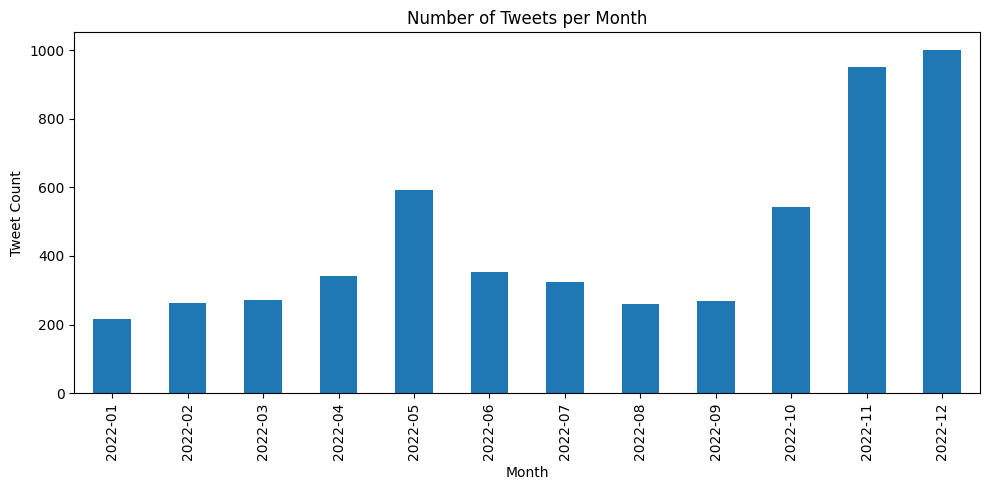

In [15]:
df['month'] = df['date'].dt.to_period('M')
tweets_per_month = df.groupby('month').size()
plt.figure(figsize=(10,5))
tweets_per_month.plot(kind='bar')
plt.title('Number of Tweets per Month')
plt.xlabel('Month')
plt.ylabel('Tweet Count')
plt.tight_layout()
plt.show()

2. Number of Tesla-related tweets (simple keyword search)

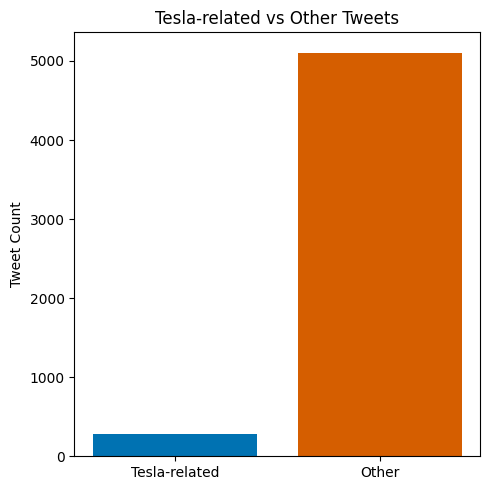

In [16]:
tesla_keywords = ['tesla', 'model', 'cybertruck', 'roadster', 'semi', 'powerwall', 'megapack', 'factory', 'gigafactory', 'production', 'delivery', 'autopilot', 'battery']
def is_tesla_related(text):
    return any(kw in text.lower() for kw in tesla_keywords)
df['tesla_related'] = df['cleaned_text'].apply(is_tesla_related)
tesla_tweet_count = df['tesla_related'].sum()
plt.figure(figsize=(5,5))
plt.bar(['Tesla-related', 'Other'], [tesla_tweet_count, len(df)-tesla_tweet_count], color=['#0072B2', '#D55E00'])
plt.title('Tesla-related vs Other Tweets')
plt.ylabel('Tweet Count')
plt.tight_layout()
plt.show()

3. Most common words (excluding stopwords, mentions, emoji text, and punctuation)

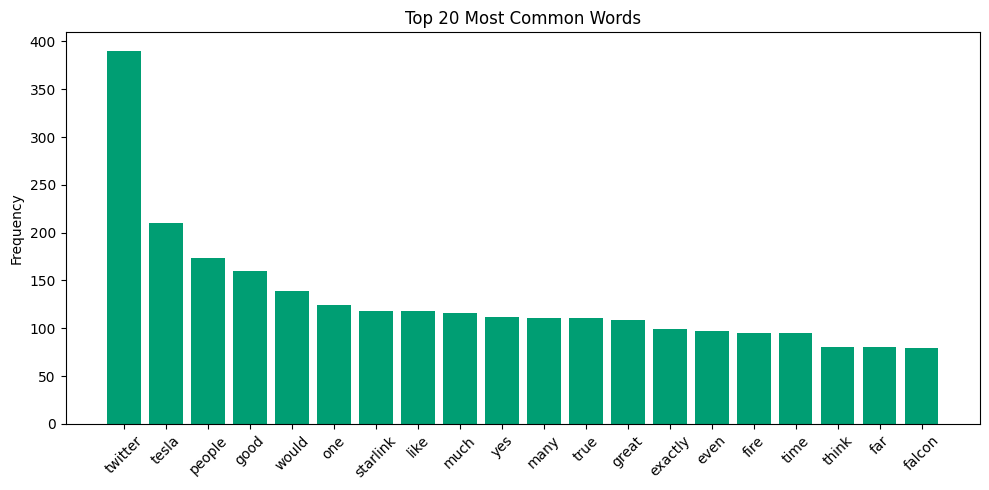

In [17]:
all_words = [
    word for tweet in df['cleaned_text'] for word in tweet.split()
    if not word.startswith(':') and word.isalpha()
]
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)
plt.figure(figsize=(10,5))
plt.bar([w for w, _ in common_words], [c for _, c in common_words], color='#009E73')
plt.title('Top 20 Most Common Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

4. Word Cloud for visualizing most frequent words

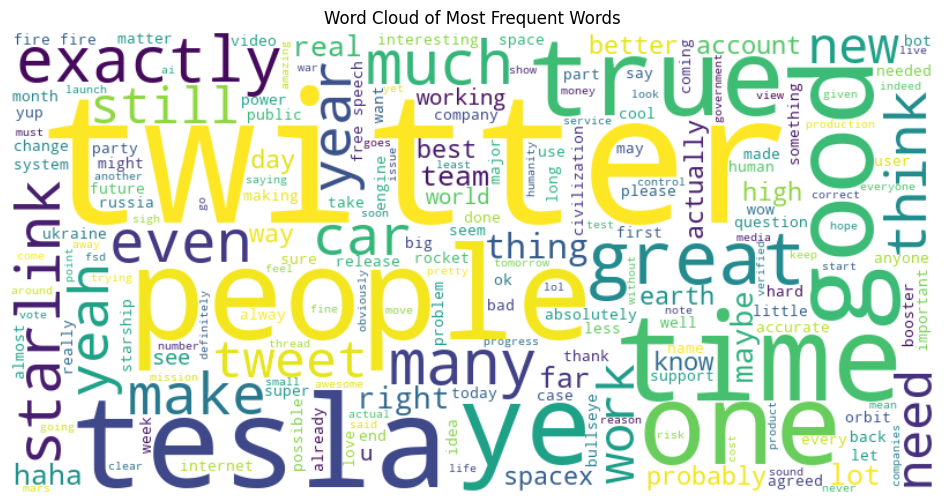

In [18]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_words))
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Frequent Words')
plt.show()

5. Tweet Length Distribution
# Calculate tweet lengths (in words)

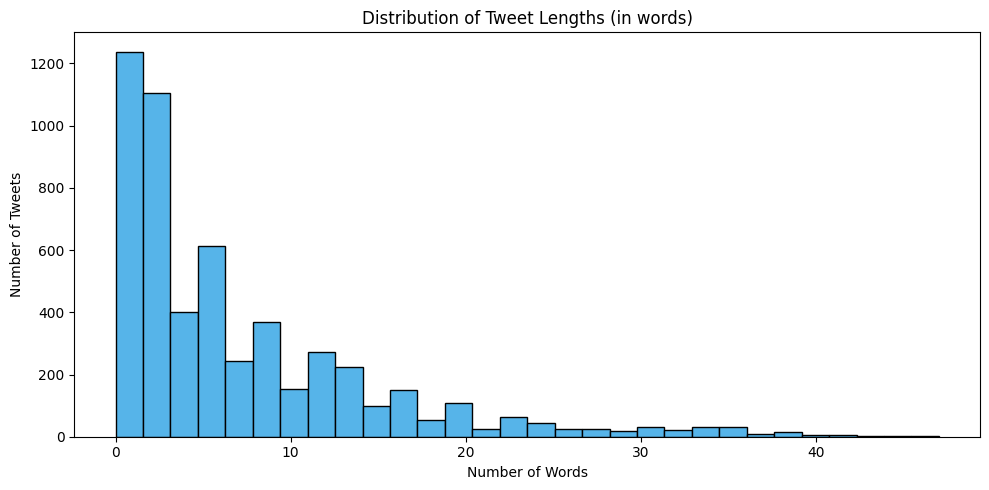

In [19]:
df['tweet_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10,5))
plt.hist(df['tweet_length'], bins=30, color='#56B4E9', edgecolor='black')
plt.title('Distribution of Tweet Lengths (in words)')
plt.xlabel('Number of Words')
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.show()

6. Trending Topics (Top 20 Bigrams)

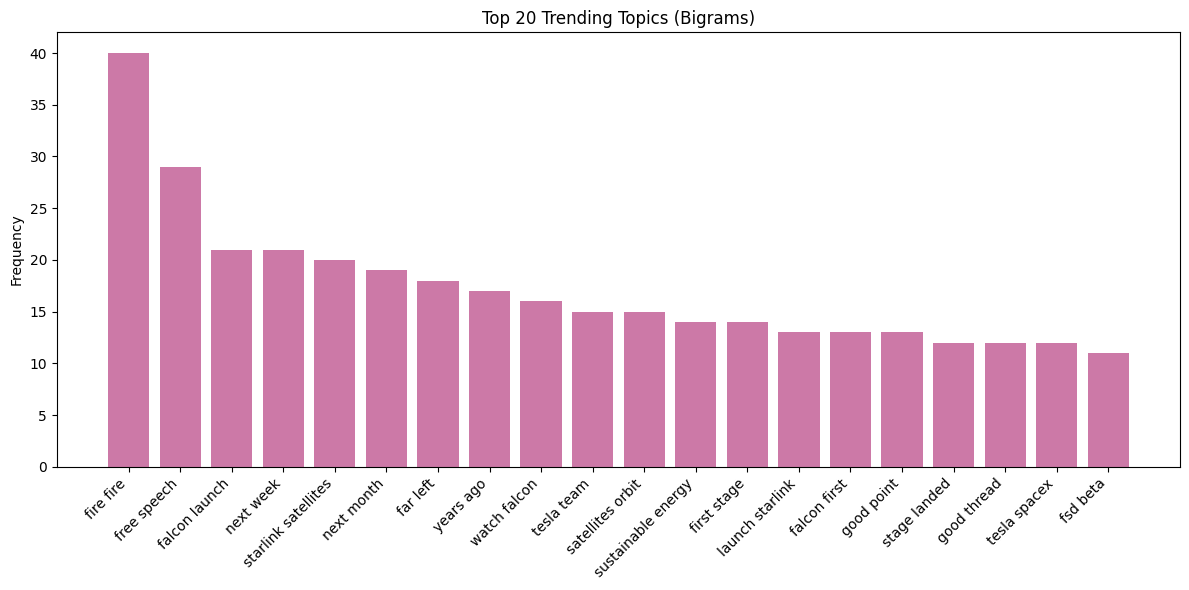

In [20]:
bigram_counter = Counter()
for tweet in df['cleaned_text']:
    tokens = [w for w in tweet.split() if w.isalpha()]
    bigrams = ngrams(tokens, 2)
    bigram_counter.update([' '.join(bigram) for bigram in bigrams])
top_bigrams = bigram_counter.most_common(20)
plt.figure(figsize=(12,6))
plt.bar([b for b, _ in top_bigrams], [c for _, c in top_bigrams], color='#CC79A7')
plt.title('Top 20 Trending Topics (Bigrams)')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 7. Sentiment Analysis
# Initialize VADER sentiment analyzer


=== Sentiment Analysis ===

Monthly sentiment analysis:
             mean  count
month                   
2022-01  0.111413    217
2022-02  0.120453    264
2022-03  0.136706    272
2022-04  0.105028    342
2022-05  0.153153    593
2022-06  0.168744    353
2022-07  0.126067    323
2022-08  0.129229    261
2022-09  0.135751    268
2022-10  0.086461    543
2022-11  0.110092    952
2022-12  0.134405   1002

Overall sentiment statistics:
count    5390.000000
mean        0.125552
std         0.347918
min        -0.950900
25%         0.000000
50%         0.000000
75%         0.401900
max         0.959300
Name: sentiment, dtype: float64

Sentiment distribution:
Positive tweets (> 0): 39.03525046382189 %
Neutral tweets (= 0): 46.84601113172542 %
Negative tweets (< 0): 14.11873840445269 %


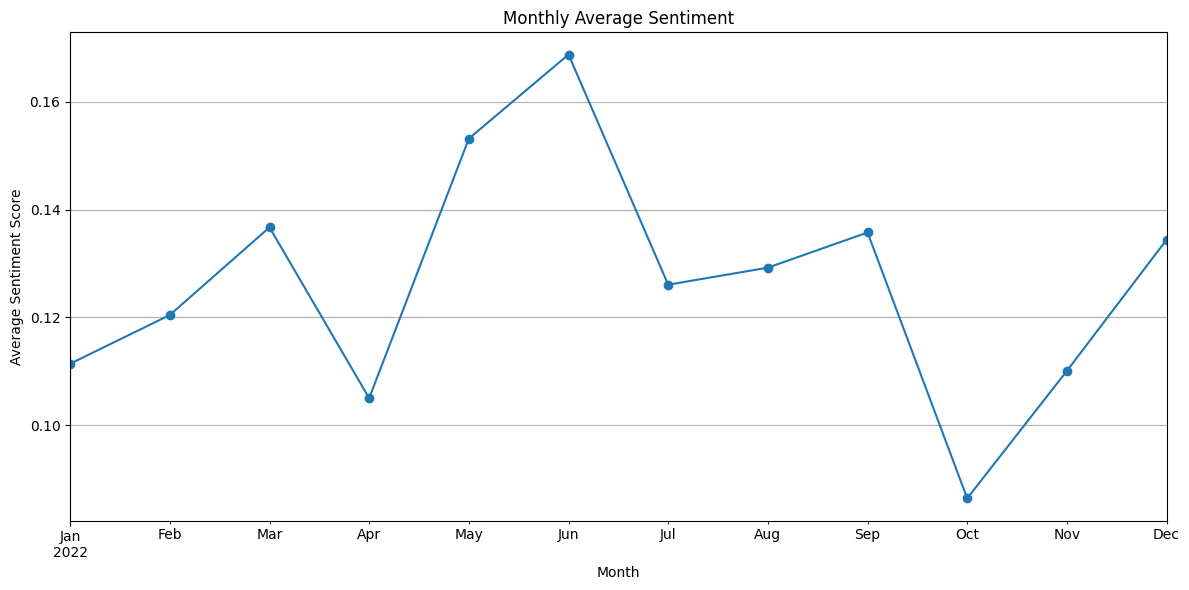

In [21]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Function to get compound sentiment score
def get_sentiment(text):
    try:
        return analyzer.polarity_scores(text)['compound']
    except:
        return 0

# Apply sentiment analysis
df['sentiment'] = df['cleaned_text'].apply(get_sentiment)

# Calculate monthly average sentiment
monthly_sentiment = df.groupby('month')['sentiment'].agg(['mean', 'count'])
monthly_sentiment = monthly_sentiment.sort_index()

print("\n=== Sentiment Analysis ===")
print("\nMonthly sentiment analysis:")
print(monthly_sentiment)

# Basic sentiment statistics
print("\nOverall sentiment statistics:")
print(df['sentiment'].describe())

# Distribution of sentiment
print("\nSentiment distribution:")
print("Positive tweets (> 0):", (df['sentiment'] > 0).mean() * 100, "%")
print("Neutral tweets (= 0):", (df['sentiment'] == 0).mean() * 100, "%")
print("Negative tweets (< 0):", (df['sentiment'] < 0).mean() * 100, "%")

# Plot monthly sentiment trends
plt.figure(figsize=(12,6))
monthly_sentiment['mean'].plot(kind='line', marker='o')
plt.title('Monthly Average Sentiment')
plt.xlabel('Month')
plt.ylabel('Average Sentiment Score')
plt.grid(True)
plt.tight_layout()
plt.show()

8. Sentiment Categorization Analysis
# Create sentiment categories

<Figure size 1500x800 with 0 Axes>

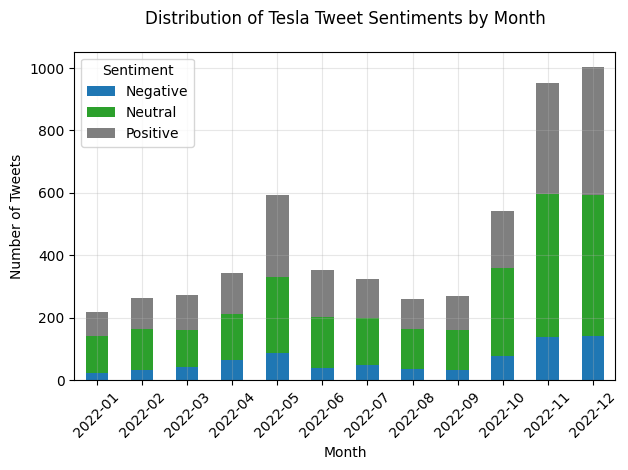

In [22]:
def categorize_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Add sentiment categories to the dataframe
df['sentiment_category'] = df['sentiment'].apply(categorize_sentiment)

# Group by month and sentiment category
monthly_categories = df.groupby(['month', 'sentiment_category']).size().unstack(fill_value=0)

# Plot sentiment distribution by month
plt.figure(figsize=(15, 8))
monthly_categories.plot(kind='bar', stacked=True,
                      color=['#1f77b4', '#2ca02c', '#7f7f7f'])  # Blue for negative, green for positive, gray for neutral

plt.title('Distribution of Tesla Tweet Sentiments by Month', fontsize=12, pad=20)
plt.xlabel('Month', fontsize=10)
plt.ylabel('Number of Tweets', fontsize=10)
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

9. Create detailed sentiment analysis TSV file

In [23]:
def get_detailed_sentiment(text):
    try:
        scores = analyzer.polarity_scores(text)
        return scores['neg'], scores['neu'], scores['pos']
    except:
        return 0, 0, 0

# Get detailed sentiment scores
df['sentiment_scores'] = df['cleaned_text'].apply(get_detailed_sentiment)
df[['NEG', 'NEU', 'POS']] = pd.DataFrame(df['sentiment_scores'].tolist(), index=df.index)

# Create output DataFrame with IDs and sentiment scores
output_df = pd.DataFrame({
    'id': elon_tweets_2022['id'],
    'NEG': df['NEG'],
    'NEU': df['NEU'],
    'POS': df['POS']
})

# Save to TSV file
output_path = r"C:\Users\qjona\OneDrive\Desktop\Year 4 Sem 2\FINA 4350\Project Codes\tweet_sentiment_scores.tsv"
output_df.to_csv(output_path, sep='\t', index=False)
print(f"\nDetailed sentiment scores saved to: {output_path}")


Detailed sentiment scores saved to: C:\Users\qjona\OneDrive\Desktop\Year 4 Sem 2\FINA 4350\Project Codes\tweet_sentiment_scores.tsv
